In [2]:
import pandas as pd
import pathlib
import rootutils
import torch
import numpy as np

rootutils.setup_root(".", indicator=".project-root", pythonpath=True)
root = pathlib.Path(rootutils.find_root("."))

from matplotlib import pyplot as plt
from matplotlib import patches
from matplotlib import gridspec as gs
from torchvision.transforms import functional as T

from src.core.data.sounding_out_chorus import SoundingOutChorus
from src.core.transforms.log_mel_spectrogram import LogMelSpectrogram
from src.core.transforms.frame import frame_fold as frame
from src.core.transforms.translation import translation_1d as translation

window_length = 192

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [3]:
data = SoundingOutChorus("/its/home/kag25/data/sounding_out", test=False)
spectrogram = LogMelSpectrogram()

In [4]:
x = spectrogram(data[2][0].unsqueeze(0)).transpose(-1, -2)
x = T.center_crop(x, [(x.size(-2) - (x.size(-2) % window_length)), x.size(-1)])
x = x.view(x.size(0), x.size(1), x.size(2) // window_length, window_length, x.size(3)).transpose(1, 2).squeeze(0)
x.shape

torch.Size([39, 1, 192, 64])

In [5]:
deltas = torch.linspace(-1, 1, 100)
x_trans = torch.stack([
    translation(x.transpose(-1, -2).contiguous(), torch.ones(x.size(0)) * delta, mode="bicubic").transpose(-1, -2).contiguous()
    for delta in deltas
], dim=1)
x_trans.shape

torch.Size([39, 100, 1, 192, 64])

tensor(28)


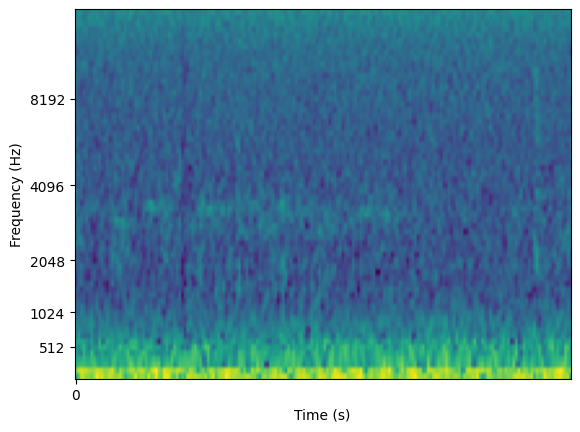

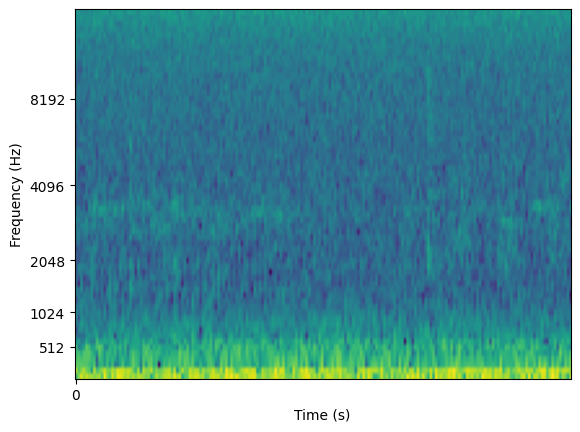

In [6]:
i = -6
mse_0 = (x.unsqueeze(1) - x_trans).pow(2).mean(dim=[-3, -2, -1])[i]
print(mse_0.argmin())
spectrogram.plot(x_trans[i, mse_0.argmin()].squeeze().t())
plt.show()
spectrogram.plot(x[i].squeeze().t())
plt.show()

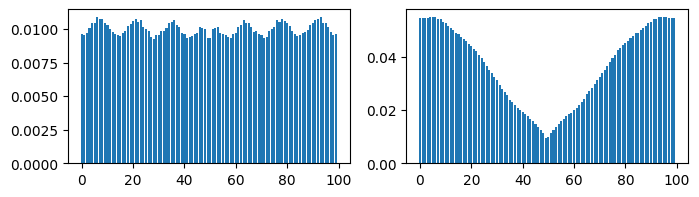

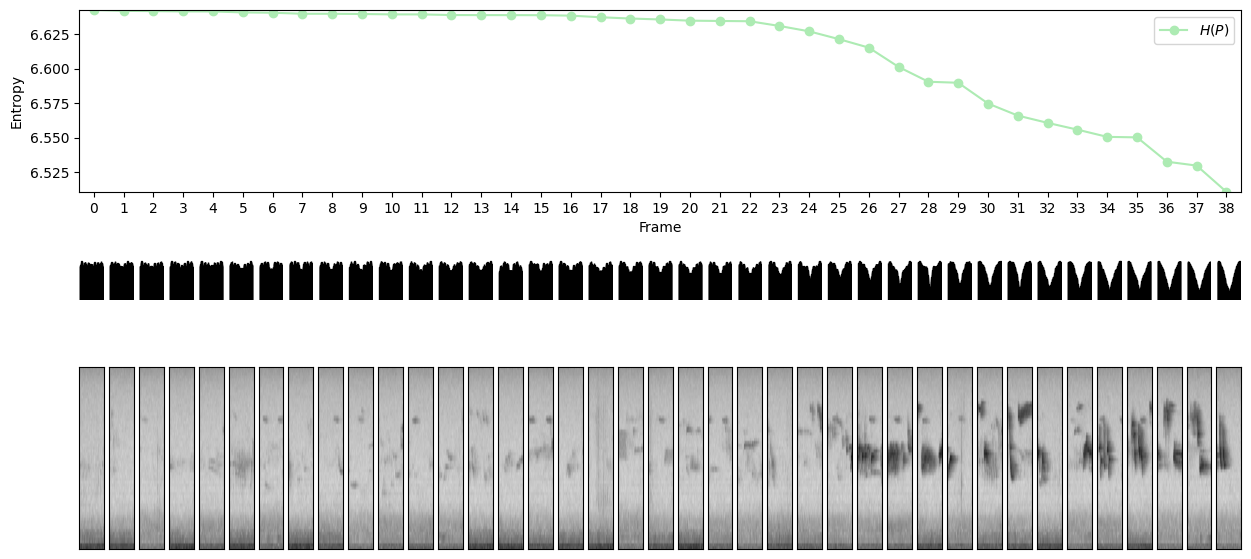

In [29]:
# calculate the mean squared error across the frame
mse = (x.unsqueeze(1) - x_trans).pow(2).flatten(start_dim=-3).sum(dim=-1)
# bin the errors across the range of shifts
kls = []
hs = []
for i in range(mse.size(0)):
    # calculate the entropy of the error
    p = (mse[i] / mse[i].sum())
    h = -((p * p.log2()).sum())
    # equivalent, the KL divergence from a uniform distribution
    kl = np.log(len(deltas)) - h
    kls.append(kl)
    hs.append(h)

kls = np.array(kls)
hs = np.array(hs)
sort_idx = np.argsort(kls)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 2))
ax1.bar(range(len(deltas)), mse[sort_idx[0]] /  mse[sort_idx[0]].sum())
ax2.bar(range(len(deltas)), mse[sort_idx[-1]] /  mse[sort_idx[0]].sum())

plt.show()

fig = plt.figure(figsize=(15, 7))
grid_spec = fig.add_gridspec(nrows=3, ncols=len(sort_idx), height_ratios=[0.45, 0.1, 0.45], hspace=0.5)

n = len(sort_idx)
x_pos = np.arange(n) + 0.5
ax = fig.add_subplot(grid_spec[0, :])
# ax.plot(x_pos, kls[sort_idx], 'o-', label=r"$D_{{KL}}(P||U)$", color="red")
ax.set_xlim(0, n)
ax.set_xticks(x_pos, labels=np.arange(n))
ax.plot(x_pos, hs[sort_idx], 'o-', label=r"$H(P)$", color="#ADEBB3")
ax.margins(x=0, y=0)
ax.patch.set_alpha(0)
ax.legend()
ax.set_facecolor("none")
ax.set_xlabel("Frame")
ax.set_ylabel("Entropy")

for i, j in enumerate(sort_idx):
    ax = fig.add_subplot(grid_spec[1, i])
    ax.bar(range(len(deltas)), mse[j] /  mse[j].sum(), facecolor='black', edgecolor='black')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
for i, j in enumerate(sort_idx):
    ax = fig.add_subplot(grid_spec[2, i])
    spectrogram.plot(x[j].squeeze().t(), vmin=x.min(), vmax=x.max(), ax=ax, cmap="Greys")
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.margins(x=0, y=0)

fig.patch.set_alpha(0)
fig.savefig(root / "frame-shift-entropy.svg", format="svg")
plt.show()

tensor([0.3969, 0.4088, 0.4122, 0.4167, 0.4288, 0.4473, 0.4713, 0.4964, 0.4689,
        0.4501, 0.4355, 0.4284, 0.4135, 0.4087, 0.4106, 0.4094, 0.4115, 0.4268,
        0.4320, 0.4535, 0.4674, 0.4762, 0.4662, 0.4402, 0.4249, 0.3964, 0.3934,
        0.3825, 0.3739, 0.3691, 0.3760, 0.3729, 0.3893, 0.3887, 0.4038, 0.4302,
        0.4082, 0.3852, 0.3617, 0.3576, 0.3375, 0.3263, 0.3167, 0.3122, 0.3106,
        0.3126, 0.3204, 0.3317, 0.3364, 0.3296, 0.3293, 0.3370, 0.3322, 0.3205,
        0.3118, 0.3108, 0.3119, 0.3168, 0.3267, 0.3384, 0.3574, 0.3618, 0.3860,
        0.4089, 0.4308, 0.4039, 0.3887, 0.3895, 0.3726, 0.3762, 0.3696, 0.3744,
        0.3828, 0.3936, 0.3965, 0.4250, 0.4407, 0.4661, 0.4772, 0.4668, 0.4530,
        0.4311, 0.4259, 0.4111, 0.4091, 0.4106, 0.4085, 0.4131, 0.4295, 0.4358,
        0.4506, 0.4703, 0.4947, 0.4699, 0.4467, 0.4291, 0.4163, 0.4125, 0.4084,
        0.3969])